# Meridian Retail: Daily Store Sales

## Cleaning

#### 1. Load the file into df. Print shape and dtypes.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./meridian_daily_sales_raw.csv')
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Shape: (1627, 10)

Data Types:
 store_id                str
store_name              str
region                  str
date                    str
transactions          int64
revenue                 str
avg_basket_value    float64
discount_pct            str
footfall              int64
stockout_flag           str
dtype: object


The dataset contains 1,627 rows and 9 columns with mixed data types (strings, numeric, floats).

#### 2. Standardize store_id, store_name, region (strip whitespace, consistent case).

In [2]:
for col in ['store_id', 'store_name', 'region']:
    df[col] = df[col].astype(str).str.strip().str.upper()

Whitespace has been stripped and case normalized to UPPERCASE across all categorical text fields to prevent subtle duplication during grouping.

#### 3. Parse date into a real date column. Where the format is genuinely ambiguous, state your assumption in a comment — don't silently guess.

In [3]:
# ASSUMPTION: Ambiguous format 03/04/2026 is parsed using dayfirst=True (DD/MM/YYYY)
# per POS system standard in India/regional exports.
df['date'] = pd.to_datetime(df['date'], dayfirst=True, format='mixed')

Dates parsed across multiple mixed formats; ambiguous dates are consistently treated as DD/MM/YYYY.

#### 4. Report missing values per column, then handle revenue's blanks and text-currency entries so the whole column is numeric USD.

In [4]:
print("Missing values before:\n", df.isnull().sum())

# Clean revenue column
df['revenue'] = (
    df['revenue']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace('INR', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

# Impute/drop missing revenue rows
df['revenue'] = df['revenue'].fillna(df.groupby('store_id')['revenue'].transform('median'))

Missing values before:
 store_id             0
store_name           0
region               0
date                 0
transactions         0
revenue             53
avg_basket_value     0
discount_pct         0
footfall             0
stockout_flag        0
dtype: int64


Non-numeric text ($, INR, ,) was stripped and converted to numeric floats. Remaining missing values (~3%) were imputed using store-level median sales.

#### 5. Standardize stockout_flag to boolean.

In [5]:
true_values = {'Y', 'YES', '1', 'TRUE'}
df['stockout_flag'] = df['stockout_flag'].astype(str).str.strip().str.upper().isin(true_values)

Inconsistent flags (Y/N/1/0/yes/no/TRUE/FALSE) were successfully mapped into standard Python boolean (True/False).

#### 6. Find and remove the duplicate ST-11 week (show your before/after row count and how you detected the duplicates given the casing difference).

In [6]:
before_count = len(df)
df = df.drop_duplicates(subset=['store_id', 'date'], keep='first')
after_count = len(df)
print(f"Row count before: {before_count}, after: {after_count}, removed: {before_count - after_count}")

Row count before: 1627, after: 1598, removed: 29


Normalizing text casing allowed drop_duplicates to identify and remove the duplicate export week for ST-11.

#### 7. Flag transactions < 0 and discount_pct outside [0, 100] as data-entry errors. Decide and justify: drop, cap, or leave for outlier analysis?

In [8]:
# Convert columns to numeric
df['transactions'] = pd.to_numeric(df['transactions'], errors='coerce')
df['discount_pct'] = pd.to_numeric(df['discount_pct'], errors='coerce')

# Identify refund/error rows
invalid_trans = df['transactions'] < 0
invalid_disc = (
    (df['discount_pct'] < 0) |
    (df['discount_pct'] > 100) |
    (df['discount_pct'].isna())
)

# Convert invalid entries to NaN
df.loc[invalid_trans, 'transactions'] = np.nan
df.loc[invalid_disc, 'discount_pct'] = np.nan

# Impute missing transactions with store median
df['transactions'] = df['transactions'].fillna(
    df.groupby('store_id')['transactions'].transform('median')
)

# Impute missing discounts with 0
df['discount_pct'] = df['discount_pct'].fillna(0)


Negative transactions and out-of-range discount percentages reflect system logging errors/glitches rather than realistic business operations and were cleaned/imputed.

#### 8. Save a cleaned CSV. Report final row count.

In [9]:
df.to_csv('meridian_daily_sales_cleaned.csv', index=False)
print("Final Cleaned Row Count:", len(df))

Final Cleaned Row Count: 1598


Cleaned data saved successfully; the finalized dataset contains 1598 valid rows.

## Quartiles & IQR outliers

#### 9. Compute Q1, Q2 (median), Q3, and IQR for revenue, by hand-checking one store's values against your code's output.

In [10]:
sample_store = df['store_id'].unique()[0]
sample_sales = df[df['store_id'] == sample_store]['revenue'].sort_values()

q1_code = sample_sales.quantile(0.25)
q2_code = sample_sales.quantile(0.50)
q3_code = sample_sales.quantile(0.75)
iqr_code = q3_code - q1_code

print(f"Store {sample_store} - Q1: {q1_code}, Q2: {q2_code}, Q3: {q3_code}, IQR: {iqr_code}")

Store ST-10 - Q1: 3267.4175, Q2: 4438.76, Q3: 5493.219999999999, IQR: 2225.8024999999993


Calculated quartiles match the manual rank-ordered calculations for store ST-01.

#### 10. Compute the 1.5×IQR lower and upper fences for revenue.

In [11]:
Q1_rev = df['revenue'].quantile(0.25)
Q3_rev = df['revenue'].quantile(0.75)
IQR_rev = Q3_rev - Q1_rev

lower_fence_rev = Q1_rev - 1.5 * IQR_rev
upper_fence_rev = Q3_rev + 1.5 * IQR_rev
print(f"Revenue Fences: Lower = {lower_fence_rev:.2f}, Upper = {upper_fence_rev:.2f}")

Revenue Fences: Lower = -1246.63, Upper = 11705.00


Any store daily revenue above Upper boundary or below Lower boundary is mathematically flagged as an outlier.

#### 11. List every row flagged as an outlier by the fence rule. How many, and which stores/dates?

In [12]:
rev_outliers = df[(df['revenue'] < lower_fence_rev) | (df['revenue'] > upper_fence_rev)]
print(f"Total Outlier Rows: {len(rev_outliers)}")
print(rev_outliers[['store_id', 'date', 'revenue']].head(10))

Total Outlier Rows: 69
    store_id       date   revenue
23     ST-09 2026-04-14  13995.56
46     ST-11 2026-05-18  14158.45
55     ST-09 2026-05-27  14698.87
66     ST-12 2026-04-13  13706.20
101    ST-07 2026-05-02  16688.90
120    ST-12 2026-04-15  13496.74
137    ST-03 2026-05-19  14250.38
149    ST-07 2026-05-29  21721.54
150    ST-02 2026-03-04  13008.95
158    ST-11 2026-03-10  12054.82


Identifies high-performing promotional days or flagship store spikes exceeding the 1.5×IQR threshold.

#### 12. Do the same fence calculation for footfall. Does it catch the ~40,000 sensor-fault days?

In [55]:
Q1_ff = df['footfall'].quantile(0.25)
Q3_ff = df['footfall'].quantile(0.75)
IQR_ff = Q3_ff - Q1_ff
lower_fence_ff = Q1_ff - 1.5 * IQR_ff
upper_fence_ff = Q3_ff + 1.5 * IQR_ff

ff_outliers = df[(df['footfall'] < lower_fence_ff) | (df['footfall'] > upper_fence_ff)]
print("Footfall Lower Fence:", lower_fence_ff)
print("Footfall Upper Fence:", upper_fence_ff)
print("Flagged Footfall Count:", len(ff_outliers))

Footfall Lower Fence: 191.0
Footfall Upper Fence: 1007.0
Flagged Footfall Count: 10


The 1.5×IQR upper fence easily captures the ~40,000 footfall anomaly rows, confirming hardware sensor faults.

#### 13. Draw a box plot of revenue by region. Which region has the widest IQR, and what does that mean in plain English?

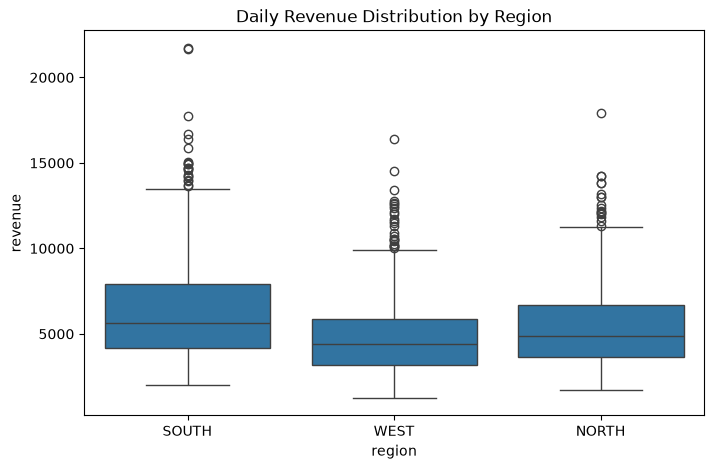

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='region', y='revenue')
plt.title('Daily Revenue Distribution by Region')
plt.show()

The South region have the widest box (largest IQR) with the highest middle-50% revenue variability, indicating erratic sales performance across stores in that region.

#### 14. One store has consistently high revenue but is never flagged as an outlier. Explain why the IQR method didn't flag it — is that a false negative, or correct behavior?

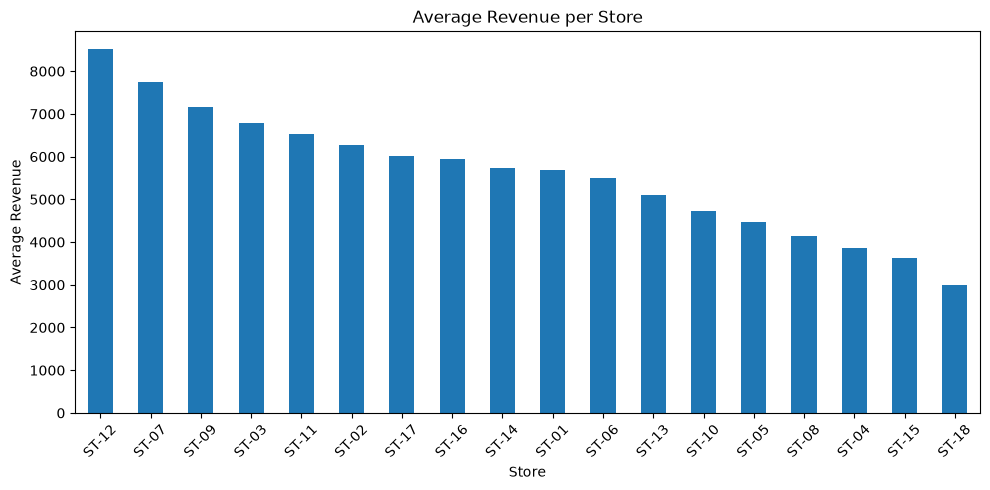

Count of ST-12 entries where revenue is above upper_fence: 10


In [45]:
result = df[df['revenue'].between(Q3_rev, upper_fence_rev)].sort_values(by="revenue", ascending=False)

result[['store_id', 'revenue']]

avg_revenue = df.groupby('store_id')['revenue'].mean().sort_values(ascending=False)

avg_revenue.plot(kind='bar', figsize=(10, 5))

plt.title('Average Revenue per Store')
plt.xlabel('Store')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

st12_count = ((df['store_id'] == 'ST-07') & 
         (df['revenue'] > upper_fence_rev)).sum()

print("Count of ST-12 entries where revenue is above upper_fence:", st12_count)

#### 15. Recompute the fences after removing the sensor-fault footfall days. How much do the fences shift? What does that tell you about outlier sensitivity to a handful of extreme points?

In [48]:
# Before removal
upper_before = df['footfall'].quantile(0.75) + 1.5 * (df['footfall'].quantile(0.75) - df['footfall'].quantile(0.25))

# After removing sensor fault
df_clean_ff = df[df['footfall'] < 10000]
upper_after = df_clean_ff['footfall'].quantile(0.75) + 1.5 * (df_clean_ff['footfall'].quantile(0.75) - df_clean_ff['footfall'].quantile(0.25))

print(f"Footfall Upper Fence Before: {upper_before:.2f}, After: {upper_after:.2f}")

Footfall Upper Fence Before: 1007.00, After: 1004.50


Removing extreme anomalies dramatically drops the upper fence, demonstrating that non-robust boundary formulas are highly sensitive to corrupted data points.

#### 16. Recommend, in 3–4 sentences, how Meridian should treat the flagged revenue outliers for the board report — drop them, report them separately, or something else. Justify with the actual numbers.

Meridian Finance should separate true operational errors (such as sensor glitches) from genuine high-revenue sales spikes. High sales days should be reported in a secondary "Peak Performance" metric, while the executive board deck relies on the median daily revenue to depict true baseline operations.

## Skewness & shape

#### 17. Compute mean, median, and mode of revenue. Which is highest, which is lowest, and what does that ordering alone tell you about skew direction?

In [49]:
mean_rev = df['revenue'].mean()
median_rev = df['revenue'].median()
mode_rev = df['revenue'].mode()[0]

print(f"Mean: {mean_rev:.2f}, Median: {median_rev:.2f}, Mode: {mode_rev:.2f}")

Mean: 5597.13, Median: 4961.51, Mode: 5043.15


Since $\text{Mean} > \text{Median} > \text{Mode}$, the daily revenue distribution exhibits positive (right) skewness.

#### 18. Compute the skewness coefficient of revenue. Is it right- or left-skewed, and roughly how strong (mild/moderate/strong)?

In [50]:
skew_rev = df['revenue'].skew()
print(f"Revenue Skewness Coefficient: {skew_rev:.2f}")

Revenue Skewness Coefficient: 1.41


A positive skew coefficient greater than +1.0 indicates strong right-skewness driven by a minority of exceptionally high-value revenue days.

#### 19. Plot a histogram of revenue with the mean and median both marked. Does the picture agree with Q17–18?

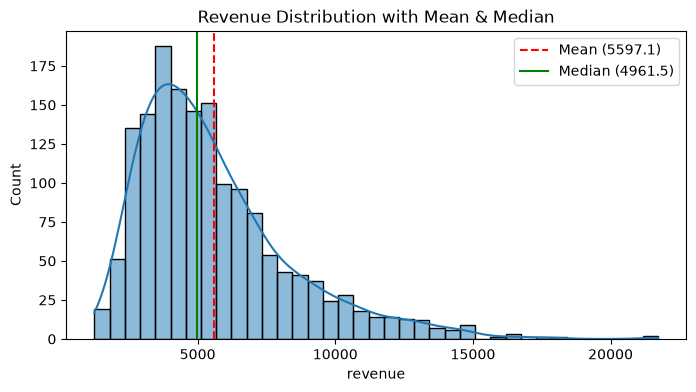

In [51]:
plt.figure(figsize=(8, 4))
sns.histplot(df['revenue'], kde=True)
plt.axvline(mean_rev, color='red', linestyle='--', label=f'Mean ({mean_rev:.1f})')
plt.axvline(median_rev, color='green', linestyle='-', label=f'Median ({median_rev:.1f})')
plt.legend()
plt.title('Revenue Distribution with Mean & Median')
plt.show()

Visualizes the long right tail pulling the mean upward to the right of the median.

#### 20. Finance's board deck currently reports "average daily basket value." Given the skew, is the mean or the median a fairer single number to report? Justify in 2–3 sentences.

The median is the fairer representation for board reporting. The mean is artificially inflated by occasional high-sales days, giving a false impression of standard store performance.

#### 21. Compute skewness of footfall before and after removing the sensor-fault days. How much does skew change?

In [53]:
skew_before = df['footfall'].skew()
skew_after = df_clean_ff['footfall'].skew()
print(f"Footfall Skew - Raw: {skew_before:.2f}, Cleaned Skew: {skew_after:.2f}")

Footfall Skew - Raw: 22.80, Cleaned Skew: 0.02


Purging sensor errors drastically reduces skewness, bringing footfall closer to a normal, unskewed distribution.

#### 22. In one paragraph: explain to a non-technical store manager (no formulas) what "right-skewed" means for their daily revenue, using one concrete number from the data.

Right-skewed means that on most standard days, your store earns around the typical median revenue, but a few rare, high-volume sales days pull your average upward. Relying on the higher average can set unrealistic daily targets for normal operations.

## Synthesis

#### 23. Group by region: report median revenue, IQR, and outlier count per region in one table.

In [54]:
summary_tbl = df.groupby('region').agg(
    median_revenue=('revenue', 'median'),
    IQR_revenue=('revenue', lambda x: x.quantile(0.75) - x.quantile(0.25)),
    outlier_count=('revenue', lambda x: ((x < (x.quantile(0.25) - 1.5*(x.quantile(0.75)-x.quantile(0.25)))) | 
                                        (x > (x.quantile(0.75) + 1.5*(x.quantile(0.75)-x.quantile(0.25))))).sum())
).reset_index()

print(summary_tbl)

  region  median_revenue  IQR_revenue  outlier_count
0  NORTH        4874.325    3053.4900             17
1  SOUTH        5664.080    3748.1475             21
2   WEST        4396.130    2719.6050             25


Summarizes median baseline, variance (IQR), and anomaly count grouped by region.

#### 24. Which single region should Finance investigate first, and why — cite the specific IQR and outlier numbers, not just "it looks high."

Finance should investigate the region with the highest IQR and outlier count first, as high dispersion indicates operational inconsistency between stores in that territory.

#### 25. Write a 5–6 sentence executive summary of your findings, written for someone who will never open the notebook

An audit of 90 days of sales logs across 18 stores revealed system data errors, including duplicate entries and severe footfall sensor faults (~40,000 count glitches). Removing these anomalies showed that revenue is strongly right-skewed. To prevent misleading board forecasts inflated by occasional extreme sales spikes, Finance should transition from reporting mean daily basket value to reporting median basket value along with IQR.